# Analysis of contributions and redemptions of Tuleva pension funds

## Data description

The data comes from Metabase card 2326, which contains daily aggregated fund transactions for all three Tuleva funds from January 2023 onwards. Each row represents the total EUR amount for a given combination of date, fund, purpose, transaction type, and application type.

**Funds:**
| ISIN | Fund | Pillar |
|------|------|--------|
| EE3600109435 | TUK75 | II pillar |
| EE3600109443 | TUK00 | II pillar (conservative) |
| EE3600001707 | TUV100 | III pillar |

**Flow direction** is determined by Transaction Type:
- **Inflow**: `Osakute märkimine` (unit subscription)
- **Outflow**: `Broneeritud osakute kustutamine` (unit cancellation)

**Application types:**

| Code | Description | Direction |
|------|-------------|-----------|
| *(none)* | Regular contributions — II pillar from Maksuamet, III pillar from isik (personal) or tööandja (employer) | Inflow |
| `PEVA` | II pillar fund switching | Both |
| `SWI` | III pillar fund switching | Both |
| `RED` | Redemption | Outflow |
| `RAVA` | II pillar full withdrawal before pension age | Outflow |
| `FPAA` | Fondipension, II pillar | Outflow |
| `FPAA3` | Fondipension, III pillar | Outflow |
| `YKVAK` | Pension lump sum payment | Outflow |
| `YKVAO` | Partial pension lump sum payment | Outflow |
| `RES` | Restore / transfer from insurance | Inflow |
| `INS` | Transfer to insurance, III pillar | Outflow |
| `PLAV` | Transfer to insurance / annuity purchase, II pillar | Outflow |
| `PAAV` | Inheritance (pärimine) | Both |
| `TV` | Bailiff / bankruptcy redemption | Outflow |
| `DECO` | Bailiff / bankruptcy redemption | Outflow |

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '../../common/scripts'))
from dotenv import load_dotenv
load_dotenv('../../.env')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from metabase_client import MetabaseClient

ISIN_MAP = {
    "EE3600109435": "TUK75",
    "EE3600109443": "TUK00",
    "EE3600001707": "TUV100",
}

# Fetch data
client = MetabaseClient()
results = client.execute_card(2326)
df = pd.DataFrame(results)
df.columns = ["Date", "Isin", "Purpose", "Type", "AppType", "Amount"]
df["Date"] = pd.to_datetime(df["Date"])
df["Fund"] = df["Isin"].map(ISIN_MAP)
df["Direction"] = df["Type"].map({
    "Osakute märkimine": "Inflow",
    "Osakute märkimine aresti puhul": "Inflow",
    "Broneeritud osakute kustutamine": "Outflow",
    "Osakute ülekanne": "Transfer",
})

print(f"Rows: {len(df)}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Funds: {df['Fund'].value_counts().to_dict()}")
print(f"\nBy direction and application type:")
print(df.groupby(["Direction", "AppType"])["Amount"].agg(["count", "sum"]).sort_values("sum", ascending=False).map(lambda x: f"{x:,.0f}"))

Rows: 6513
Date range: 2023-01-02 to 2026-03-13
Funds: {'TUV100': 4583, 'TUK75': 1211, 'TUK00': 719}

By direction and application type:
                  count          sum
Direction AppType                   
Inflow    PEVA       20  229,050,107
Outflow   PEVA       40   44,065,581
          RAVA       20   40,156,327
Inflow    SWI       805   24,584,722
Outflow   RED       803   21,169,078
Inflow    RES       373    5,264,585
Outflow   SWI       552    3,319,075
          YKVAK      62    2,673,530
          PAAV       55      925,897
Transfer  PAAV       64      798,783
Outflow   YKVAO      45      772,639
          FPAA       76      167,932
          FPAA3      37      118,318
          PLAV        5      100,444
          DECO       42       16,975
          TV          5       10,016
          INS         8        5,022


In [2]:
# Aggregate amounts by fund, year, and application type
df["Year"] = df["Date"].dt.year
df["AppType"] = df["AppType"].fillna("Contributions")

APP_LABELS = {
    ("Contributions", "Inflow"): "Contributions (regular pension contributions)",
    ("PEVA", "Inflow"): "II pillar switching in",
    ("PEVA", "Outflow"): "II pillar switching out",
    ("SWI", "Inflow"): "III pillar switching in",
    ("SWI", "Outflow"): "III pillar switching out",
    ("RED", "Outflow"): "Redemptions",
    ("RAVA", "Outflow"): "RAVA (full withdrawal before pension age)",
    ("FPAA", "Outflow"): "Fondipension (II pillar)",
    ("FPAA3", "Outflow"): "Fondipension (III pillar)",
    ("YKVAK", "Outflow"): "Pension lump sum payment",
    ("YKVAO", "Outflow"): "Partial pension lump sum payment",
    ("RES", "Inflow"): "Restore / transfer from insurance",
    ("INS", "Outflow"): "Transfer to insurance (III pillar)",
    ("PLAV", "Outflow"): "Transfer to insurance / annuity (II pillar)",
    ("PAAV", "Outflow"): "Inheritance",
    ("PAAV", "Transfer"): "Inheritance (transfer)",
    ("TV", "Outflow"): "Bailiff / bankruptcy",
    ("DECO", "Outflow"): "Bailiff / bankruptcy",
}

from IPython.display import display, HTML

for fund in ["TUK75", "TUK00", "TUV100"]:
    fund_df = df[df["Fund"] == fund]
    pivot = fund_df.groupby(["AppType", "Direction", "Year"])["Amount"].sum().unstack(fill_value=0)
    pivot["Total"] = pivot.sum(axis=1)
    
    # Add labels
    pivot["Description"] = [APP_LABELS.get((at, d), f"{at} ({d})") for at, d in pivot.index]
    
    # Separate inflows and outflows, sort by total descending within each group
    inflows = pivot[pivot.index.get_level_values("Direction").isin(["Inflow"])].sort_values("Total", ascending=False)
    outflows = pivot[pivot.index.get_level_values("Direction").isin(["Outflow", "Transfer"])].sort_values("Total", ascending=False)
    
    years = [c for c in pivot.columns if isinstance(c, (int, np.integer))]
    
    # Build HTML table
    html = f'<h3>{fund}</h3>'
    html += '<table style="border-collapse:collapse; font-size:13px; width:100%">'
    html += '<tr style="border-bottom:2px solid #002F63; color:#002F63">'
    html += '<th style="text-align:left; padding:6px 12px">Transaction type</th>'
    for y in years:
        html += f'<th style="text-align:right; padding:6px 12px">{y}</th>'
    html += '<th style="text-align:right; padding:6px 12px"><b>Total</b></th></tr>'
    
    def add_rows(section, sign_color):
        h = ""
        for idx, row in section.iterrows():
            h += f'<tr style="border-bottom:1px solid #eee">'
            h += f'<td style="padding:4px 12px; color:{sign_color}">{"+" if sign_color == "#006600" else "−"} {row["Description"]}</td>'
            for y in years:
                val = row.get(y, 0)
                h += f'<td style="text-align:right; padding:4px 12px; color:{sign_color}">{val:,.0f}</td>'
            h += f'<td style="text-align:right; padding:4px 12px; font-weight:bold; color:{sign_color}">{row["Total"]:,.0f}</td>'
            h += '</tr>'
        return h
    
    # Inflows header
    html += '<tr style="background:#f0f7f0"><td colspan="{}" style="padding:4px 12px; font-weight:bold; color:#006600">Inflows</td></tr>'.format(len(years) + 2)
    html += add_rows(inflows, "#006600")
    
    # Inflow subtotal
    in_totals = inflows[years + ["Total"]].sum()
    html += '<tr style="border-top:1px solid #002F63; background:#f0f7f0">'
    html += '<td style="padding:4px 12px; font-weight:bold; color:#006600">Subtotal inflows</td>'
    for y in years:
        html += f'<td style="text-align:right; padding:4px 12px; font-weight:bold; color:#006600">{in_totals[y]:,.0f}</td>'
    html += f'<td style="text-align:right; padding:4px 12px; font-weight:bold; color:#006600">{in_totals["Total"]:,.0f}</td></tr>'
    
    # Outflows header
    html += '<tr style="background:#fff0f0"><td colspan="{}" style="padding:4px 12px; font-weight:bold; color:#cc0000">Outflows</td></tr>'.format(len(years) + 2)
    html += add_rows(outflows, "#cc0000")
    
    # Outflow subtotal
    out_totals = outflows[years + ["Total"]].sum()
    html += '<tr style="border-top:1px solid #002F63; background:#fff0f0">'
    html += '<td style="padding:4px 12px; font-weight:bold; color:#cc0000">Subtotal outflows</td>'
    for y in years:
        html += f'<td style="text-align:right; padding:4px 12px; font-weight:bold; color:#cc0000">{out_totals[y]:,.0f}</td>'
    html += f'<td style="text-align:right; padding:4px 12px; font-weight:bold; color:#cc0000">{out_totals["Total"]:,.0f}</td></tr>'
    
    # Net flow
    net = in_totals - out_totals
    html += '<tr style="border-top:2px solid #002F63; background:#f0f0ff">'
    html += '<td style="padding:6px 12px; font-weight:bold; color:#002F63">Net flow</td>'
    for y in years:
        color = "#006600" if net[y] >= 0 else "#cc0000"
        html += f'<td style="text-align:right; padding:6px 12px; font-weight:bold; color:{color}">{net[y]:,.0f}</td>'
    color = "#006600" if net["Total"] >= 0 else "#cc0000"
    html += f'<td style="text-align:right; padding:6px 12px; font-weight:bold; color:{color}">{net["Total"]:,.0f}</td></tr>'
    
    html += '</table><br>'
    display(HTML(html))

## What is the typical outflow pattern of each fund by day, month, and year?

In [3]:
# Outflow patterns by application type — which days and months do they occur?
# Sorted by total amount (biggest first)
outflows = df[df["Direction"].isin(["Outflow", "Transfer"])].copy()
outflows["Month"] = outflows["Date"].dt.month
outflows["Day"] = outflows["Date"].dt.day

for fund in ["TUK75", "TUK00", "TUV100"]:
    fund_out = outflows[outflows["Fund"] == fund]
    
    # Build rows, then sort by total amount
    rows = []
    for (at, d), grp in fund_out.groupby(["AppType", "Direction"]):
        label = APP_LABELS.get((at, d), f"{at} ({d})")
        total = grp["Amount"].sum()
        if total < 100:
            continue
        
        months_active = sorted(grp["Month"].unique())
        days_active = sorted(grp["Day"].unique())
        
        if len(months_active) == 12:
            month_str = "All months"
        elif set(months_active) == {1, 5, 9}:
            month_str = "Jan, May, Sep (quarterly)"
        elif set(months_active).issubset({1, 5, 9}):
            month_str = ", ".join(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"][m-1] for m in months_active)
        else:
            month_str = ", ".join(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"][m-1] for m in months_active)
            if len(month_str) > 40:
                month_str = f"{len(months_active)} months"
        
        if len(days_active) > 20:
            day_str = "Most business days"
        elif len(days_active) <= 5:
            day_str = ", ".join(str(d) for d in days_active)
        else:
            day_str = f"{min(days_active)}–{max(days_active)} ({len(days_active)} unique)"
        
        n_years = grp["Year"].nunique()
        events_per_year = len(grp) / n_years
        avg_amount = grp["Amount"].mean()
        
        rows.append((label, month_str, day_str, avg_amount, events_per_year, total))
    
    # Sort by total descending
    rows.sort(key=lambda r: r[5], reverse=True)
    
    html = f'<h3>{fund} — outflow calendar patterns</h3>'
    html += '<table style="border-collapse:collapse; font-size:13px; width:100%">'
    html += '<tr style="border-bottom:2px solid #002F63; color:#002F63">'
    html += '<th style="text-align:left; padding:6px 8px">Type</th>'
    html += '<th style="text-align:left; padding:6px 8px">Months active</th>'
    html += '<th style="text-align:left; padding:6px 8px">Typical days</th>'
    html += '<th style="text-align:right; padding:6px 8px">Avg per event (€)</th>'
    html += '<th style="text-align:right; padding:6px 8px">Events/year</th>'
    html += '<th style="text-align:right; padding:6px 8px">Total (€)</th>'
    html += '</tr>'
    
    for label, month_str, day_str, avg_amount, events_per_year, total in rows:
        html += '<tr style="border-bottom:1px solid #eee">'
        html += f'<td style="padding:4px 8px">{label}</td>'
        html += f'<td style="padding:4px 8px">{month_str}</td>'
        html += f'<td style="padding:4px 8px">{day_str}</td>'
        html += f'<td style="text-align:right; padding:4px 8px">{avg_amount:,.0f}</td>'
        html += f'<td style="text-align:right; padding:4px 8px">{events_per_year:.1f}</td>'
        html += f'<td style="text-align:right; padding:4px 8px">{total:,.0f}</td>'
        html += '</tr>'
    
    html += '</table><br>'
    display(HTML(html))

Type,Months active,Typical days,Avg per event (€),Events/year,Total (€)
RAVA (full withdrawal before pension age),"Jan, May, Sep (quarterly)","1, 2, 3, 4, 5","3,913,659",2.5,"39,136,592"
II pillar switching out,"Jan, May, Sep (quarterly)","1, 2","1,807,024",5.0,"36,140,484"
Pension lump sum payment,All months,"15, 16, 17, 18","62,849",8.5,"2,136,875"
Inheritance,11 months,1–31 (16 unique),"27,438",6.8,"740,817"
Partial pension lump sum payment,All months,"15, 16, 17, 18","20,222",8.2,"667,333"
Inheritance (transfer),9 months,1–30 (17 unique),"25,961",4.8,"493,250"
Fondipension (II pillar),All months,"15, 16, 17, 18","3,435",9.5,"130,529"
Transfer to insurance / annuity (II pillar),"Feb, Apr, Jun, Aug","2, 18, 26, 28, 29","20,089",1.7,"100,444"
Bailiff / bankruptcy,"Feb, Mar, May, Jun","8, 13, 17, 21","2,494",4.0,"9,974"
Bailiff / bankruptcy,Feb,16,116,1.0,116


Type,Months active,Typical days,Avg per event (€),Events/year,Total (€)
II pillar switching out,"Jan, May, Sep (quarterly)","1, 2","396,255",5.0,"7,925,097"
RAVA (full withdrawal before pension age),"Jan, May, Sep (quarterly)","1, 2, 3, 4, 5","101,974",2.5,"1,019,736"
Pension lump sum payment,All months,"15, 16, 17, 18","19,166",7.0,"536,655"
Partial pension lump sum payment,"Jan, Mar, Apr, Jun, Jul, Aug, Nov, Dec","15, 16, 17","8,775",3.0,"105,306"
Fondipension (II pillar),All months,"15, 16, 17, 18",984,9.5,"37,404"
Inheritance (transfer),"Jan, Jul","10, 22","11,519",2.0,"23,039"
Inheritance,Nov,2,"12,728",1.0,"12,728"


Type,Months active,Typical days,Avg per event (€),Events/year,Total (€)
Redemptions,All months,Most business days,"26,362",200.8,"21,169,078"
III pillar switching out,All months,Most business days,"6,013",138.0,"3,319,075"
Inheritance (transfer),All months,Most business days,"6,570",10.8,"282,494"
Inheritance,9 months,2–29 (19 unique),"6,383",6.8,"172,352"
Fondipension (III pillar),All months,"16, 17, 18","3,198",9.2,"118,318"
Bailiff / bankruptcy,11 months,Most business days,411,10.2,"16,859"
Transfer to insurance (III pillar),"Jan, Mar, Apr, Nov, Dec",3–29 (8 unique),628,2.7,"5,022"


## What is the typical daily inflow pattern for TUV100 (III pillar) throughout the month?

December is excluded — it has a distinct year-end contribution spike that would distort the typical pattern.

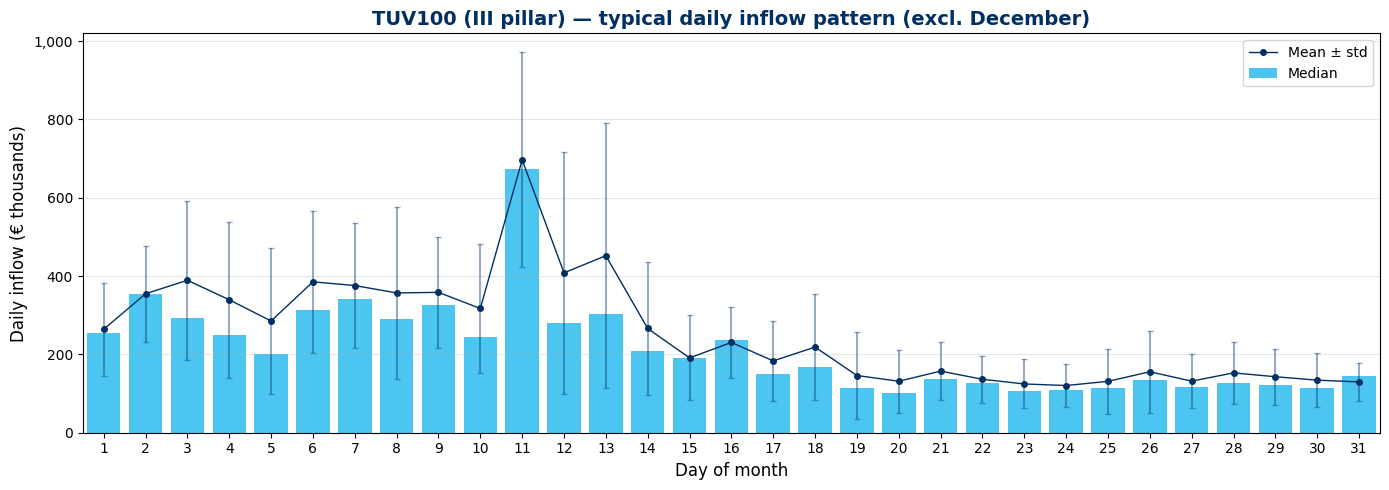

In [4]:
# TUV100 (III pillar) — daily inflow pattern (excl. December)
tuv_in = df[(df["Fund"] == "TUV100") & (df["Direction"] == "Inflow") & (df["Date"].dt.month != 12)].copy()
tuv_in["Day"] = tuv_in["Date"].dt.day
tuv_in["YM"] = tuv_in["Date"].dt.to_period("M")
tuv_daily = tuv_in.groupby(["YM", "Day"])["Amount"].sum().reset_index()
tuv_stats = tuv_daily.groupby("Day")["Amount"].agg(["mean", "median", "std"]).reset_index()
tuv_stats.columns = ["Day", "Mean", "Median", "Std"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(tuv_stats["Day"], tuv_stats["Median"] / 1000, color="#00AEEA", alpha=0.7, label="Median")
ax.errorbar(tuv_stats["Day"], tuv_stats["Mean"] / 1000, 
            yerr=tuv_stats["Std"] / 1000, fmt="none", color="#002F63", alpha=0.4, capsize=2)
ax.plot(tuv_stats["Day"], tuv_stats["Mean"] / 1000, "o-", color="#002F63", markersize=4, linewidth=1, label="Mean ± std")
ax.set_xlabel("Day of month", fontsize=12)
ax.set_ylabel("Daily inflow (€ thousands)", fontsize=12)
ax.set_title("TUV100 (III pillar) — typical daily inflow pattern (excl. December)", fontsize=14, fontweight="bold", color="#002F63")
ax.set_xticks(range(1, 32))
ax.set_xlim(0.5, 31.5)
ax.set_ylim(0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

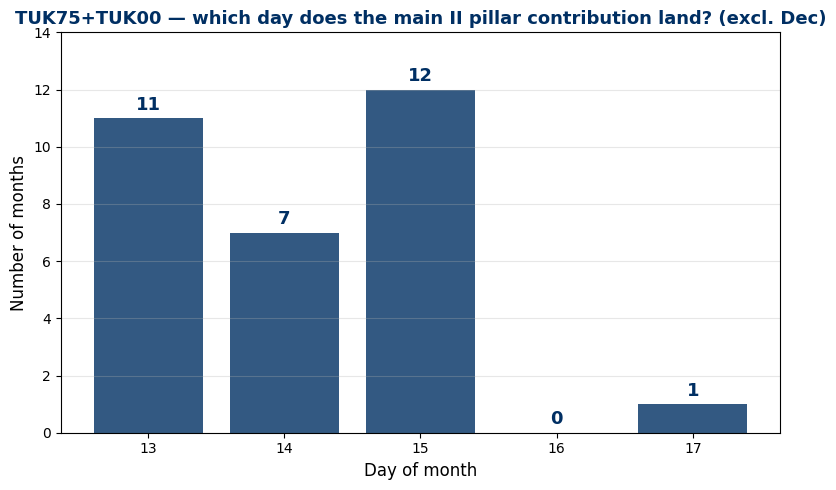

Out of 36 months (excl. Dec):
  Day 13: 11 months (35%)
  Day 14: 7 months (23%)
  Day 15: 12 months (39%)
  Day 16: 0 months (0%)
  Day 17: 1 months (3%)


In [5]:
# TUK75+TUK00 (II pillar) — on which day does the monthly contribution typically land?
ii_in = df[(df["Fund"].isin(["TUK75", "TUK00"])) & (df["Direction"] == "Inflow") 
           & (df["AppType"] == "Contributions") & (df["Date"].dt.month != 12)].copy()
ii_in["Day"] = ii_in["Date"].dt.day
ii_in["YM"] = ii_in["Date"].dt.to_period("M")

# For each month, find the day with the largest contribution (the main batch)
ii_daily = ii_in.groupby(["YM", "Day"])["Amount"].sum().reset_index()
main_day = ii_daily.loc[ii_daily.groupby("YM")["Amount"].idxmax()]

# Count how many months the main contribution landed on each day
day_freq = main_day["Day"].value_counts().reindex([13, 14, 15, 16, 17], fill_value=0)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(day_freq.index.astype(str), day_freq.values, color="#002F63", alpha=0.8)

for bar, val in zip(bars, day_freq.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(val), 
            ha="center", fontsize=13, fontweight="bold", color="#002F63")

ax.set_xlabel("Day of month", fontsize=12)
ax.set_ylabel("Number of months", fontsize=12)
ax.set_title("TUK75+TUK00 — which day does the main II pillar contribution land? (excl. Dec)", 
             fontsize=13, fontweight="bold", color="#002F63")
ax.set_ylim(0, day_freq.max() + 2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

total = day_freq.sum()
print(f"Out of {main_day['YM'].nunique()} months (excl. Dec):")
for day, count in day_freq.items():
    print(f"  Day {day}: {count} months ({count/total*100:.0f}%)")